# MAGPIE Zero-Shot Evaluation on German News

This notebook contains the main analysis carried out for the thesis **“Zero-Shot Cross-Lingual Media Bias Detection: Applying MAGPIE to German News at the Article Level.”**

The aim of the analysis is to examine how well the English-trained MAGPIE model transfers to German news articles without any additional German-language fine-tuning. In particular, the analysis looks at whether the model's sentence-level bias predictions show a systematic difference between articles labelled as politically left- or right-leaning.

Since MAGPIE produces predictions at the sentence level, the sentence-level scores are aggregated to obtain article-level scores. Different pooling methods are compared to check whether the results are consistent across aggregation strategies.

### Main analysis
- Continuous average pooling
- Max pooling
- Median pooling

### Robustness and sensitivity checks
- Hard-label average pooling
- Top-3 and top-5 pooling
- Article-length controls
- Restricted-length sensitivity analysis
- HC3 robust standard errors
- Outlet-clustered standard errors

### Additional analysis
- Outlet-level score patterns
- Exploratory genre analysis
- Comparison with the SentiWS lexicon

**Dataset:** German subset of `poliOscar.complete.de`  
**Model:** `mediabiasgroup/magpie-babe-ft-xlm`  
**Sample:** 1,000 German news articles (500 left-labelled and 500 right-labelled), selected using random seed 42.

The notebook is designed to be run from top to bottom. This keeps the data preparation, model scoring, statistical tests, and figures within one reproducible analysis workflow.

## 1. Setup

The required packages are installed first, followed by the necessary Python imports and the MAGPIE model setup. The notebook uses a GPU automatically when one is available.

### Run order

Run the notebook **from top to bottom** to keep the analysis reproducible. The scoring section processes sentence-level predictions in batches rather than running the Transformer separately for each article, which helps reduce unnecessary model overhead.

The corpus file `poliOscar.complete.de` should be placed in the same working directory as the notebook.

In [1]:
from pathlib import Path

corpus_path = Path("poliOscar.complete.de")
if not corpus_path.exists():
    raise FileNotFoundError(
        "poliOscar.complete.de was not found. Upload the corpus to the Colab working directory "
        "and run the notebook again."
    )

print("Corpus file found:", corpus_path)


Corpus file found: poliOscar.complete.de


In [2]:
!pip install transformers pandas scikit-learn scipy statsmodels tqdm datasets -q


In [3]:
import re
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statistics
import statsmodels.formula.api as smf
import torch
from datasets import load_dataset
from scipy.stats import kruskal, mannwhitneyu, spearmanr
from tqdm import tqdm
from transformers import pipeline

MODEL_NAME = "mediabiasgroup/magpie-babe-ft-xlm"
RANDOM_SEED = 42

device = 0 if torch.cuda.is_available() else -1
print("Model device:", "GPU" if device == 0 else "CPU")

bias_classifier = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=device,
)

Model device: GPU


config.json:   0%|          | 0.00/835 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

## 2. Data loading and reproducible sampling

The German corpus is loaded from `poliOscar.complete.de`. The loader identifies the start of each article record and keeps the following lines as part of the article text, so line breaks within an article are preserved correctly.

Articles with empty text are excluded before sampling. The final sample contains 500 articles labelled **left** and 500 labelled **right**, selected using a fixed random seed for reproducibility.

In [4]:
# Read the corpus while preserving line breaks within article text.

columns = ["topic10", "topic15", "stance", "oscarID", "url", "text"]

rows = []
current = None

with open("poliOscar.complete.de", "r", encoding="utf-8") as f:
    for raw_line in f:
        line = raw_line.rstrip("\r\n")
        parts = line.split("\t", 5)

        if len(parts) >= 5 and parts[2] in ["left", "right"]:
            if current is not None:
                rows.append(current)

            while len(parts) < 6:
                parts.append("")

            current = parts[:6]
        elif current is not None:
            current[5] += "\n" + line

if current is not None:
    rows.append(current)

df = pd.DataFrame(rows, columns=columns)

print("Full corpus shape:", df.shape)
print("\nStance distribution:")
print(df["stance"].value_counts())
print("\nRecords with missing article text:", df["text"].str.strip().eq("").sum())

Full corpus shape: (143200, 6)

Stance distribution:
stance
left     88102
right    55098
Name: count, dtype: int64

Records with missing article text: 3081


In [5]:
df_usable = df[df["text"].str.strip().ne("")].copy()

left_sample = df_usable[df_usable["stance"] == "left"].sample(n=500, random_state=42)
right_sample = df_usable[df_usable["stance"] == "right"].sample(n=500, random_state=42)

df_sample = (
    pd.concat([left_sample, right_sample])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

assert len(df_sample) == 1000
assert df_sample["stance"].value_counts().to_dict() == {"left": 500, "right": 500}
assert df_sample["text"].str.strip().ne("").all()

print("Analysis corpus with usable text:", df_usable.shape)
print("Sample shape:", df_sample.shape)
print(df_sample["stance"].value_counts())


assert df_sample["oscarID"].is_unique
assert df_sample["url"].is_unique


Analysis corpus with usable text: (140119, 6)
Sample shape: (1000, 6)
stance
right    500
left     500
Name: count, dtype: int64


In [6]:
sample_record = df_sample[["oscarID", "url", "stance"]].copy()

print("Sample shape:", df_sample.shape)
print("Unique oscarID values:", sample_record["oscarID"].nunique())
print("Unique URL values:", sample_record["url"].nunique())
print("Duplicate oscarID count:", sample_record["oscarID"].duplicated().sum())
print("Duplicate URL count:", sample_record["url"].duplicated().sum())
print("\nStance counts:")
print(sample_record["stance"].value_counts())

sample_record.to_csv("german_sample_1000_identifiers.csv", index=False)
print("\nSaved german_sample_1000_identifiers.csv")


Sample shape: (1000, 6)
Unique oscarID values: 1000
Unique URL values: 1000
Duplicate oscarID count: 0
Duplicate URL count: 0

Stance counts:
stance
right    500
left     500
Name: count, dtype: int64

Saved german_sample_1000_identifiers.csv


In [7]:
print("Full corpus records:", len(df))
print("Records with usable article text:", len(df_usable))
print("Records excluded for missing article text:", len(df) - len(df_usable))
print("\nSample empty-text records:", df_sample["text"].str.strip().eq("").sum())


Full corpus records: 143200
Records with usable article text: 140119
Records excluded for missing article text: 3081

Sample empty-text records: 0


## 3. Sentence splitting and MAGPIE scoring

MAGPIE produces a bias probability for each sentence. These sentence-level scores are then combined to obtain an article-level score using several pooling methods.

The **continuous average** is used as the primary average-pooling measure because it keeps the probability information from the model. The hard-label proportion is included as a sensitivity measure, while max, median, top-3, and top-5 pooling are examined separately.

In [8]:
def split_into_sentences(text):
    paragraphs = text.split("<NS>")
    sentences = []

    for paragraph in paragraphs:
        paragraph = paragraph.strip()
        if not paragraph:
            continue

        parts = re.split(r"(?<=[.!?]) +", paragraph)
        sentences.extend(part.strip() for part in parts if part.strip())

    return sentences


def score_articles_batched(texts, classifier, batch_size=32):
    """Score all article sentences in batches and return article-level measures."""
    article_sentences = []
    all_sentences = []

    for text in texts:
        if pd.isna(text) or not text.strip():
            sentences = []
        else:
            sentences = split_into_sentences(text)

        article_sentences.append(sentences)
        all_sentences.extend(sentences)

    if not all_sentences:
        return [(None,) * 6 for _ in texts]

    sentence_results = []
    for start in tqdm(
        range(0, len(all_sentences), batch_size),
        desc="Scoring sentences",
    ):
        batch = all_sentences[start:start + batch_size]
        sentence_results.extend(
            classifier(batch, truncation=True, batch_size=batch_size)
        )

    article_scores = []
    cursor = 0

    for sentences in article_sentences:
        n_sentences = len(sentences)

        if n_sentences == 0:
            article_scores.append((None,) * 6)
            continue

        results = sentence_results[cursor:cursor + n_sentences]
        cursor += n_sentences

        biased_probs = [
            result["score"]
            if result["label"].lower() == "biased"
            else 1 - result["score"]
            for result in results
        ]

        hard_average = sum(
            result["label"].lower() == "biased" for result in results
        ) / n_sentences
        continuous_average = sum(biased_probs) / n_sentences
        max_score = max(biased_probs)
        median_score = statistics.median(biased_probs)

        sorted_probs = sorted(biased_probs, reverse=True)
        top3_average = sum(sorted_probs[:3]) / min(3, n_sentences)
        top5_average = sum(sorted_probs[:5]) / min(5, n_sentences)

        article_scores.append(
            (
                hard_average,
                continuous_average,
                max_score,
                median_score,
                top3_average,
                top5_average,
            )
        )

    return article_scores


In [9]:
article_scores = score_articles_batched(
    df_sample["text"].tolist(),
    bias_classifier,
    batch_size=32,
)

(
    hard_scores,
    continuous_scores,
    max_scores,
    median_scores,
    top3_scores,
    top5_scores,
) = map(list, zip(*article_scores))

df_sample["bias_score"] = hard_scores
df_sample["bias_score_continuous"] = continuous_scores
df_sample["max_bias_score"] = max_scores
df_sample["median_bias_score"] = median_scores
df_sample["top3_avg"] = top3_scores
df_sample["top5_avg"] = top5_scores

print("Scored articles:", df_sample["bias_score"].notna().sum())
print("Unscored articles:", df_sample["bias_score"].isna().sum())


Scoring sentences: 100%|██████████| 1228/1228 [00:47<00:00, 25.79it/s]

Scored articles: 1000
Unscored articles: 0


## 4. Primary left/right comparisons

The primary comparisons examine whether article-level MAGPIE scores differ between the left- and right-labelled groups.

The **continuous average** is used as the main average-pooling measure. The hard-label average is included only as a sensitivity analysis.

In [10]:
def mw_result(column):
    left = df_sample.loc[df_sample["stance"] == "left", column].dropna()
    right = df_sample.loc[df_sample["stance"] == "right", column].dropna()
    statistic, p_value = mannwhitneyu(left, right, alternative="two-sided")
    return left, right, statistic, p_value

left_avg_cont, right_avg_cont, _, p_avg_continuous = mw_result("bias_score_continuous")
left_avg_hard, right_avg_hard, _, p_avg_hard = mw_result("bias_score")
left_max, right_max, _, p_max = mw_result("max_bias_score")
left_median, right_median, _, p_median = mw_result("median_bias_score")

print(f"Continuous average: left={left_avg_cont.mean():.4f}, right={right_avg_cont.mean():.4f}, p={p_avg_continuous:.4f}")
print(f"Hard-label average: left={left_avg_hard.mean():.4f}, right={right_avg_hard.mean():.4f}, p={p_avg_hard:.4f}")
print(f"Max: left={left_max.mean():.4f}, right={right_max.mean():.4f}, p={p_max:.4f}")
print(f"Median: left={left_median.mean():.4f}, right={right_median.mean():.4f}, p={p_median:.4f}")


Continuous average: left=0.2924, right=0.3101, p=0.0569
Hard-label average: left=0.2366, right=0.2499, p=0.4830
Max: left=0.8503, right=0.8271, p=0.0035
Median: left=0.2065, right=0.2336, p=0.0010


In [11]:
def rank_biserial(left, right):
    u_stat, _ = mannwhitneyu(left, right, alternative="two-sided")
    return 1 - (2 * u_stat) / (len(left) * len(right))

for name, left, right in [
    ("Average (continuous)", left_avg_cont, right_avg_cont),
    ("Average (hard-label)", left_avg_hard, right_avg_hard),
    ("Max", left_max, right_max),
    ("Median", left_median, right_median),
]:
    print(f"{name}: rank-biserial={rank_biserial(left, right):.4f}")


Average (continuous): rank-biserial=0.0696
Average (hard-label): rank-biserial=0.0256
Max: rank-biserial=-0.1067
Median: rank-biserial=0.1199


## 5. Article length and regression checks

Article length is considered because pooling sentence-level scores may be influenced by the number of sentences in an article. Regression models are therefore used to examine the relationship with political stance while controlling for sentence count.

In [12]:
df_sample["num_sentences"] = df_sample["text"].apply(
    lambda text: len(split_into_sentences(text)) if pd.notna(text) else np.nan
)
df_sample["stance_numeric"] = (df_sample["stance"] == "left").astype(int)

print(df_sample.groupby("stance")["num_sentences"].agg(["mean", "median", "count"]))
print("\nCorrelation matrix:")
print(df_sample[["num_sentences", "bias_score_continuous", "max_bias_score", "median_bias_score"]].corr())


          mean  median  count
stance                       
left    46.124    34.0    500
right   32.436    22.0    500

Correlation matrix:
                       num_sentences  bias_score_continuous  max_bias_score  \
num_sentences               1.000000               0.143946        0.322051   
bias_score_continuous       0.143946               1.000000        0.577909   
max_bias_score              0.322051               0.577909        1.000000   
median_bias_score           0.056984               0.916679        0.342504   

                       median_bias_score  
num_sentences                   0.056984  
bias_score_continuous           0.916679  
max_bias_score                  0.342504  
median_bias_score               1.000000  


In [13]:
model_avg_continuous = smf.ols(
    "bias_score_continuous ~ stance_numeric + num_sentences", data=df_sample
).fit()
model_avg_hard = smf.ols(
    "bias_score ~ stance_numeric + num_sentences", data=df_sample
).fit()
model_max = smf.ols(
    "max_bias_score ~ stance_numeric + num_sentences", data=df_sample
).fit()
model_median = smf.ols(
    "median_bias_score ~ stance_numeric + num_sentences", data=df_sample
).fit()

for name, model in [
    ("Continuous average", model_avg_continuous),
    ("Hard-label average", model_avg_hard),
    ("Max", model_max),
    ("Median", model_median),
]:
    print(f"{name}: stance coefficient={model.params['stance_numeric']:.4f}, p={model.pvalues['stance_numeric']:.4f}, R²={model.rsquared:.3f}")


Continuous average: stance coefficient=-0.0247, p=0.0094, R²=0.027
Hard-label average: stance coefficient=-0.0206, p=0.0817, R²=0.019
Max: stance coefficient=0.0010, p=0.9438, R²=0.104
Median: stance coefficient=-0.0310, p=0.0115, R²=0.010


### HC3 sensitivity

HC3 heteroskedasticity-robust standard errors are included as a sensitivity check for the regression results.

In [14]:
for name, model in [
    ("Continuous average", model_avg_continuous),
    ("Hard-label average", model_avg_hard),
    ("Max", model_max),
    ("Median", model_median),
]:
    robust = model.get_robustcov_results(cov_type="HC3")
    print(f"{name}: HC3 stance p={robust.pvalues[1]:.4f}")


Continuous average: HC3 stance p=0.0096
Hard-label average: HC3 stance p=0.0810
Max: HC3 stance p=0.9439
Median: HC3 stance p=0.0114


### Restricted-length sensitivity

A restricted sample of articles containing between 10 and 60 sentences is used as an additional sensitivity analysis. This narrows the range of article lengths without treating the groups as formally matched.

In [15]:
df_restricted = df_sample[df_sample["num_sentences"].between(10, 60)].copy()
left_restricted = df_restricted.loc[df_restricted["stance"] == "left", "max_bias_score"].dropna()
right_restricted = df_restricted.loc[df_restricted["stance"] == "right", "max_bias_score"].dropna()
_, p_restricted = mannwhitneyu(left_restricted, right_restricted, alternative="two-sided")

print(df_restricted.groupby("stance")["num_sentences"].agg(["mean", "median", "count"]))
print(f"Left mean={left_restricted.mean():.4f}")
print(f"Right mean={right_restricted.mean():.4f}")
print(f"p={p_restricted:.4f}")
print(f"rank-biserial={rank_biserial(left_restricted, right_restricted):.4f}")


             mean  median  count
stance                          
left    31.724432    30.5    352
right   26.460641    24.0    343
Left mean=0.8677
Right mean=0.8800
p=0.8604
rank-biserial=-0.0077


### Bonferroni correction for the six primary German tests

Six tests are treated as the primary German hypothesis family. Using the Bonferroni correction, the significance threshold is set to \(0.05/6 = 0.0083\).

In [16]:
primary_results = {
    "Average pooling (continuous)": p_avg_continuous,
    "Max pooling (naive)": p_max,
    "Max pooling + length regression": model_max.pvalues["stance_numeric"],
    "Max pooling, restricted length": p_restricted,
    "Median pooling (naive)": p_median,
    "Median pooling + length regression": model_median.pvalues["stance_numeric"],
}

bonferroni_alpha = 0.05 / len(primary_results)
print(f"Bonferroni threshold={bonferroni_alpha:.4f}")
for name, p_value in primary_results.items():
    print(f"{name}: p={p_value:.4f}; {'significant' if p_value < bonferroni_alpha else 'not significant'}")


Bonferroni threshold=0.0083
Average pooling (continuous): p=0.0569; not significant
Max pooling (naive): p=0.0035; significant
Max pooling + length regression: p=0.9438; not significant
Max pooling, restricted length: p=0.8604; not significant
Median pooling (naive): p=0.0010; significant
Median pooling + length regression: p=0.0115; not significant


## 6. Length visualisation

The following figures show how max MAGPIE scores are distributed and how they relate to article length.

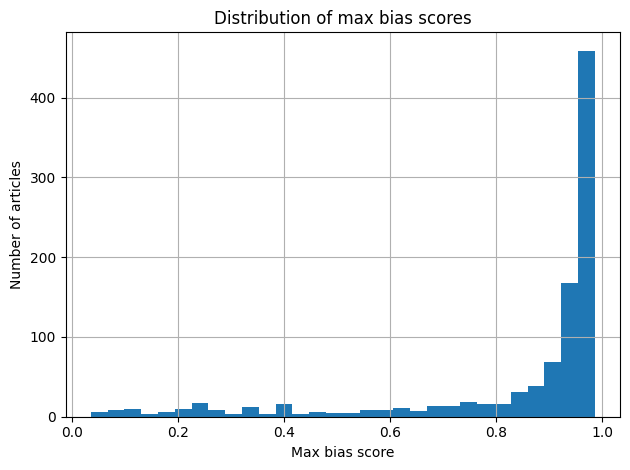

In [17]:
df_sample["max_bias_score"].hist(bins=30)
plt.xlabel("Max bias score")
plt.ylabel("Number of articles")
plt.title("Distribution of max bias scores")
plt.tight_layout()
plt.show()


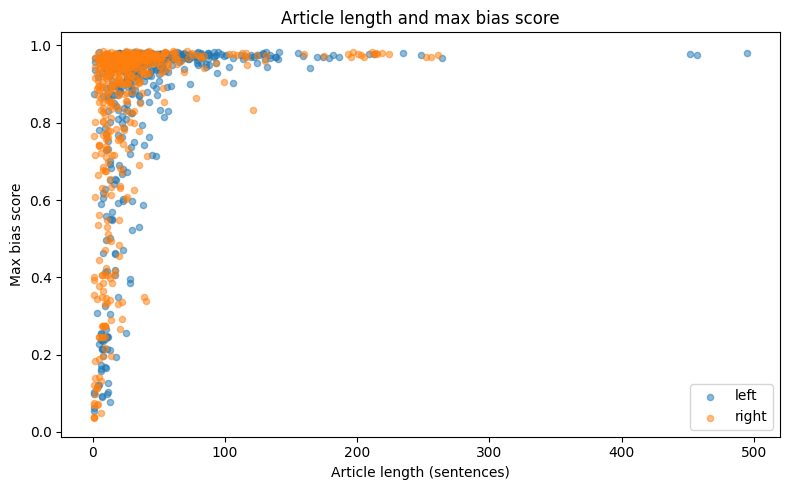

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
for stance, group in df_sample.groupby("stance"):
    ax.scatter(group["num_sentences"], group["max_bias_score"], alpha=0.5, s=20, label=stance)
ax.set_xlabel("Article length (sentences)")
ax.set_ylabel("Max bias score")
ax.set_title("Article length and max bias score")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Top-k pooling robustness

Top-3 and top-5 pooling focus on the highest sentence-level bias probabilities within each article. These measures are included as **robustness analyses** rather than as additional primary hypothesis tests.

In [19]:
# Top-3 and top-5 scores were calculated during the main scoring pass.
print("Top-k scores available:", df_sample[["top3_avg", "top5_avg"]].notna().all().all())


Top-k scores available: True


In [20]:
for column, name in [("top3_avg", "Top-3"), ("top5_avg", "Top-5")]:
    left = df_sample.loc[df_sample["stance"] == "left", column].dropna()
    right = df_sample.loc[df_sample["stance"] == "right", column].dropna()
    _, p_value = mannwhitneyu(left, right, alternative="two-sided")
    print(f"{name}: left={left.mean():.4f}, right={right.mean():.4f}, p={p_value:.4f}, rank-biserial={rank_biserial(left, right):.4f}")

print("\nLength correlations:")
print(df_sample[["num_sentences", "top3_avg", "top5_avg"]].corr())


Top-3: left=0.7743, right=0.7243, p=0.0000, rank-biserial=-0.1560
Top-5: left=0.7160, right=0.6467, p=0.0000, rank-biserial=-0.1673

Length correlations:
               num_sentences  top3_avg  top5_avg
num_sentences       1.000000  0.425717  0.479782
top3_avg            0.425717  1.000000  0.973206
top5_avg            0.479782  0.973206  1.000000


In [21]:
model_top3 = smf.ols("top3_avg ~ stance_numeric + num_sentences", data=df_sample).fit()
model_top5 = smf.ols("top5_avg ~ stance_numeric + num_sentences", data=df_sample).fit()

for name, model in [("Top-3", model_top3), ("Top-5", model_top5)]:
    hc3 = model.get_robustcov_results(cov_type="HC3")
    print(f"{name}: OLS stance p={model.pvalues['stance_numeric']:.4f}; HC3 stance p={hc3.pvalues[1]:.4f}; R²={model.rsquared:.3f}")


Top-3: OLS stance p=0.2705; HC3 stance p=0.2707; R²=0.182
Top-5: OLS stance p=0.0603; HC3 stance p=0.0598; R²=0.233


Top-k results are treated as robustness evidence rather than additional primary tests. Their strong association with article length is important because the method specifically selects the highest sentence-level scores.

## 8. Outlet and genre structure

The next analyses look at how MAGPIE scores vary across news outlets and between articles flagged as opinion/commentary and other articles.

These analyses are descriptive and exploratory. They are not intended to establish a causal relationship between outlet, genre, and political stance.

In [22]:
df_sample["outlet"] = df_sample["url"].apply(
    lambda url: urlparse(url).netloc.lower().replace("www.", "")
)

outlet_counts = df_sample["outlet"].value_counts()
outlets_with_enough_data = outlet_counts[outlet_counts >= 20].index
df_outlets = df_sample[df_sample["outlet"].isin(outlets_with_enough_data)].copy()

outlet_summary = df_outlets.groupby("outlet")["bias_score_continuous"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
print("Distinct outlets:", df_sample["outlet"].nunique())
print("Outlets with at least 20 sampled articles:", len(outlets_with_enough_data))
print("\nUsable-score outlet summary:")
print(outlet_summary)


Distinct outlets: 12
Outlets with at least 20 sampled articles: 8

Usable-score outlet summary:
                      mean    median  count
outlet                                     
jungefreiheit.de  0.354814  0.321245     81
taz.de            0.327888  0.314324    213
welt.de           0.320202  0.302647     79
nd-aktuell.de     0.303272  0.312761     43
faz.net           0.299617  0.283219    121
bild.de           0.295814  0.289477    214
sueddeutsche.de   0.278911  0.257793    173
jungewelt.de      0.187323  0.176902     41


In [23]:
groups = [group["bias_score_continuous"].dropna().values for _, group in df_outlets.groupby("outlet")]
stat_outlet, p_outlet = kruskal(*groups)
print(f"Kruskal-Wallis H={stat_outlet:.4f}, p={p_outlet:.4f}, outlets={len(groups)}")


Kruskal-Wallis H=45.4287, p=0.0000, outlets=8


### Genre rule

An article is flagged as opinion/commentary when its URL contains `kommentar`, `meinung`, `kolumne`, `gastbeitrag`, or `leitartikel`.

This is an exploratory URL-based rule rather than a validated genre classifier. The hard-label average is used here because it was the measure originally implemented for this exploratory analysis. It is not used as the primary article-level measure elsewhere in the notebook.

In [24]:
opinion_keywords = ["kommentar", "meinung", "kolumne", "gastbeitrag", "leitartikel"]

df_sample["is_opinion"] = df_sample["url"].str.lower().apply(
    lambda url: any(keyword in url for keyword in opinion_keywords)
)

opinion_scores = df_sample.loc[df_sample["is_opinion"], "bias_score"].dropna()
news_scores = df_sample.loc[~df_sample["is_opinion"], "bias_score"].dropna()
_, p_genre = mannwhitneyu(opinion_scores, news_scores, alternative="two-sided")

print(f"Opinion/commentary hard-label score: mean={opinion_scores.mean():.4f}, n={len(opinion_scores)}")
print(f"Straight-news hard-label score: mean={news_scores.mean():.4f}, n={len(news_scores)}")
print(f"p={p_genre:.4f}")


Opinion/commentary hard-label score: mean=0.4609, n=35
Straight-news hard-label score: mean=0.2354, n=965
p=0.0000


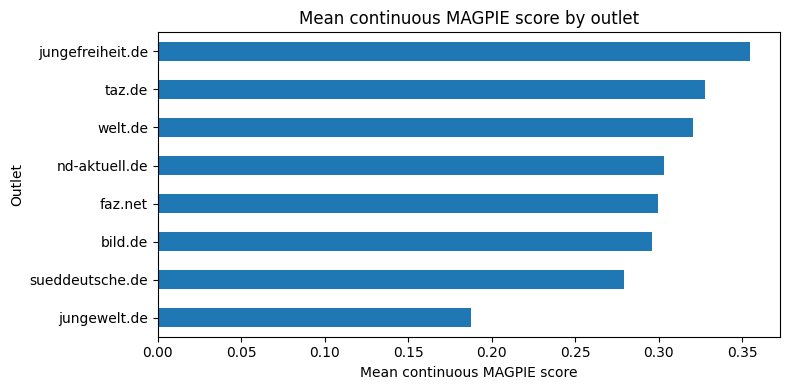

In [25]:
outlet_summary["mean"].sort_values().plot(
    kind="barh", figsize=(8, max(4, len(outlet_summary) * 0.35))
)
plt.xlabel("Mean continuous MAGPIE score")
plt.ylabel("Outlet")
plt.title("Mean continuous MAGPIE score by outlet")
plt.tight_layout()
plt.show()


### Manual genre spot-check

A small set of examples is printed to check whether the URL-based rule appears reasonable. This is only a qualitative check and is **not** used to estimate precision or recall.

In [26]:
sample_opinion = df_sample[df_sample["is_opinion"]].sample(n=min(5, int(df_sample["is_opinion"].sum())), random_state=42)
sample_news = df_sample[~df_sample["is_opinion"]].sample(n=5, random_state=42)

print("=== Flagged as opinion/commentary ===")
for _, row in sample_opinion.iterrows():
    print(f"\nURL: {row['url']}\nText start: {row['text'][:200]}...")

print("\n=== Not flagged as opinion/commentary ===")
for _, row in sample_news.iterrows():
    print(f"\nURL: {row['url']}\nText start: {row['text'][:200]}...")


=== Flagged as opinion/commentary ===

URL: https://jungefreiheit.de/debatte/kommentar/2018/metapolitik-und-die-lage/
Text start: Skulptur „Der Rufer“ auf der Straße des 17. Juni vor dem Brandenburger Tor in Berlin Foto: picture alliance/dpa <NS> Meinung <NS> Metapolitik und die Lage <NS> 18. Februar 2018 <NS> Martin Sellner von...

URL: https://www.bild.de/politik/ausland/europaeische-union/kommentar-von-kai-weise-53205262.bild.html
Text start: Wer führt Europa in die Zukunft? EU-Kommissionspräsident Jean-Claude Juncker hat es gestern versucht. <NS> Aber seine Rede zur Lage der Europäischen Union geht an der Wirklichkeit vorbei. <NS> Europa ...

URL: https://taz.de/Kolumne-Die-eine-Frage/!5021162/
Text start: Der Silicon-Valley-Milliardär Peter Thiel treibt die libertaristische Idee ins Extreme. Er will die entwickelte Welt weiterentwickeln. <NS> Die Zukunft liegt in neuen Investitionen – zum Beispiel in d...

URL: https://jungefreiheit.de/debatte/kommentar/2020/das-naerrische-treiben

### Outlet-clustering assessment

Political stance is assigned at the outlet level. In this sample, each outlet has a single stance label, so stance is completely nested within outlet.

For this reason, outlet-clustered standard errors are used only as a **sensitivity analysis**. They do not remove the underlying outlet-level confounding or provide independent article-level political labels.


In [27]:
print("Total distinct outlets:", df_sample["outlet"].nunique())
print("\nArticles per outlet:")
print(df_sample["outlet"].value_counts())

outlet_stance_counts = df_sample.groupby("outlet")["stance"].nunique()
mixed_stance = outlet_stance_counts[outlet_stance_counts > 1]
print("\nOutlets with mixed stance labels:", len(mixed_stance))
print("Distinct outlets by stance:")
print(df_sample.groupby("stance")["outlet"].nunique())
print("\nArticle counts by outlet and stance:")
print(df_sample.groupby(["outlet", "stance"]).size().unstack(fill_value=0))


Total distinct outlets: 12

Articles per outlet:
outlet
bild.de             214
taz.de              213
sueddeutsche.de     173
faz.net             121
jungefreiheit.de     81
welt.de              79
nd-aktuell.de        43
jungewelt.de         41
dw.com               13
staz.de              10
blogs.taz.de          7
paz.de                5
Name: count, dtype: int64

Outlets with mixed stance labels: 0
Distinct outlets by stance:
stance
left     7
right    5
Name: outlet, dtype: int64

Article counts by outlet and stance:
stance            left  right
outlet                       
bild.de              0    214
blogs.taz.de         7      0
dw.com              13      0
faz.net              0    121
jungefreiheit.de     0     81
jungewelt.de        41      0
nd-aktuell.de       43      0
paz.de               0      5
staz.de             10      0
sueddeutsche.de    173      0
taz.de             213      0
welt.de              0     79


In [28]:
models_to_check = {
    "Average (continuous)": ("bias_score_continuous", model_avg_continuous),
    "Average (hard-label)": ("bias_score", model_avg_hard),
    "Max": ("max_bias_score", model_max),
    "Median": ("median_bias_score", model_median),
    "Top-3": ("top3_avg", model_top3),
    "Top-5": ("top5_avg", model_top5),
}

for name, (column, model) in models_to_check.items():
    used_rows = model.model.data.row_labels
    data_used = df_sample.loc[used_rows]
    clustered = smf.ols(
        f"{column} ~ stance_numeric + num_sentences",
        data=data_used
    ).fit(cov_type="cluster", cov_kwds={"groups": data_used["outlet"]})
    print(f"{name}: coefficient={model.params['stance_numeric']:.4f}, cluster-robust p={clustered.pvalues['stance_numeric']:.4f}")


Average (continuous): coefficient=-0.0247, cluster-robust p=0.2398
Average (hard-label): coefficient=-0.0206, cluster-robust p=0.4477
Max: coefficient=0.0010, cluster-robust p=0.9818
Median: coefficient=-0.0310, cluster-robust p=0.1842
Top-3: coefficient=0.0169, cluster-robust p=0.7608
Top-5: coefficient=0.0298, cluster-robust p=0.6018


## 9. SentiWS lexicon baseline

SentiWS provides a weighted German sentiment lexicon. This comparison examines whether the article-level MAGPIE scores are related to a separate lexical signal.

The lexicon analysis is used as a baseline comparison. It does not imply that MAGPIE and SentiWS measure exactly the same construct.

In [29]:
sentiws_data = load_dataset("community-datasets/senti_ws", "sentiment-scoring", split="train")
sentiws = {}
for row in sentiws_data:
    word = row["word"].lower()
    score = row.get("sentiment-score", row.get("sentiment_score"))
    sentiws[word] = score

print("Lexicon entries:", len(sentiws))


README.md:   0%|          | 0.00/5.22k [00:00<?, ?B/s]

sentiment-scoring/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 45.1kB            

sentiment-scoring/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3471 [00:00<?, ? examples/s]

Lexicon entries: 3459


In [30]:
def lexicon_score_sentence(sentence):
    words = re.findall(r"[a-zA-ZäöüÄÖÜß]+", sentence.lower())
    weights = [abs(sentiws[word]) for word in words if word in sentiws]
    return sum(weights) / len(weights) if weights else 0.0


def lexicon_score_article(text):
    if pd.isna(text) or not text.strip():
        return None, None, None
    sentences = split_into_sentences(text)
    if not sentences:
        return None, None, None
    scores = [lexicon_score_sentence(sentence) for sentence in sentences]
    return sum(scores) / len(scores), max(scores), statistics.median(scores)


In [31]:
lex_avg = []
lex_max = []
lex_median = []

for text in tqdm(df_sample["text"].tolist(), desc="Calculating lexicon scores"):
    avg, maximum, median = lexicon_score_article(text)
    lex_avg.append(avg)
    lex_max.append(maximum)
    lex_median.append(median)

df_sample["lex_avg"] = lex_avg
df_sample["lex_max"] = lex_max
df_sample["lex_median"] = lex_median


Calculating lexicon scores: 100%|██████████| 1000/1000 [00:00<00:00, 2432.59it/s]


In [32]:
for column, name in [("lex_avg", "Average"), ("lex_max", "Max"), ("lex_median", "Median")]:
    left = df_sample.loc[df_sample["stance"] == "left", column].dropna()
    right = df_sample.loc[df_sample["stance"] == "right", column].dropna()
    _, p_value = mannwhitneyu(left, right, alternative="two-sided")
    print(f"{name}: left={left.mean():.4f}, right={right.mean():.4f}, p={p_value:.4f}")
print("Bonferroni threshold:", 0.05 / 3)


Average: left=0.0639, right=0.0697, p=0.1642
Max: left=0.5133, right=0.4646, p=0.0002
Median: left=0.0056, right=0.0082, p=0.0236
Bonferroni threshold: 0.016666666666666666


In [33]:
for magpie_col, lex_col, name in [
    ("bias_score_continuous", "lex_avg", "Average"),
    ("max_bias_score", "lex_max", "Max"),
    ("median_bias_score", "lex_median", "Median"),
]:
    valid = df_sample[[magpie_col, lex_col]].dropna()
    rho, p_value = spearmanr(valid[magpie_col], valid[lex_col])
    print(f"{name}: Spearman rho={rho:.4f}, p={p_value:.4f}")


Average: Spearman rho=0.2191, p=0.0000
Max: Spearman rho=0.4015, p=0.0000
Median: Spearman rho=0.1067, p=0.0007


### Interpretation note

A statistically significant result from one pooling strategy is not interpreted on its own. The overall interpretation considers the primary test family, article length, robustness checks, and the outlet-level structure of the stance labels.

Because stance is perfectly nested within outlet, outlet clustering is used only as a sensitivity analysis. The results are therefore interpreted as evidence **from the observed sample and measurement setup**, rather than as definitive evidence that MAGPIE cannot detect political bias in German text.

## 10. Final result summary

The final cell brings together the main statistics from the analysis. Since the values are taken directly from the analysis variables, they are updated automatically when the notebook is rerun.


In [34]:
print("PRIMARY RESULTS")
print(
    f"Continuous average: left={left_avg_cont.mean():.4f}, "
    f"right={right_avg_cont.mean():.4f}, p={p_avg_continuous:.4f}, "
    f"rank-biserial={rank_biserial(left_avg_cont, right_avg_cont):.4f}"
)
print(
    f"Max: left={left_max.mean():.4f}, right={right_max.mean():.4f}, "
    f"p={p_max:.4f}, length-controlled p={model_max.pvalues['stance_numeric']:.4f}"
)
print(
    f"Median: left={left_median.mean():.4f}, right={right_median.mean():.4f}, "
    f"p={p_median:.4f}, length-controlled p={model_median.pvalues['stance_numeric']:.4f}"
)
print(f"Restricted max: p={p_restricted:.4f}")
print(
    f"Top-3: left={df_sample.loc[df_sample.stance == 'left', 'top3_avg'].mean():.4f}, "
    f"right={df_sample.loc[df_sample.stance == 'right', 'top3_avg'].mean():.4f}, "
    f"OLS p={model_top3.pvalues['stance_numeric']:.4f}"
)
print(
    f"Top-5: left={df_sample.loc[df_sample.stance == 'left', 'top5_avg'].mean():.4f}, "
    f"right={df_sample.loc[df_sample.stance == 'right', 'top5_avg'].mean():.4f}, "
    f"OLS p={model_top5.pvalues['stance_numeric']:.4f}"
)

print("\nOUTLET-CLUSTERED SENSITIVITY")
for name, (column, model) in models_to_check.items():
    used_rows = model.model.data.row_labels
    data_used = df_sample.loc[used_rows]
    clustered = smf.ols(
        f"{column} ~ stance_numeric + num_sentences",
        data=data_used,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": data_used["outlet"]},
    )
    print(
        f"{name}: coefficient={model.params['stance_numeric']:.4f}, "
        f"cluster-robust p={clustered.pvalues['stance_numeric']:.4f}"
    )

print("\nLEXICON ASSOCIATIONS")
for magpie_col, lex_col, name in [
    ("bias_score_continuous", "lex_avg", "Average"),
    ("max_bias_score", "lex_max", "Max"),
    ("median_bias_score", "lex_median", "Median"),
]:
    valid = df_sample[[magpie_col, lex_col]].dropna()
    rho, p_value = spearmanr(valid[magpie_col], valid[lex_col])
    print(f"{name}: Spearman rho={rho:.4f}, p={p_value:.4f}")


PRIMARY RESULTS
Continuous average: left=0.2924, right=0.3101, p=0.0569, rank-biserial=0.0696
Max: left=0.8503, right=0.8271, p=0.0035, length-controlled p=0.9438
Median: left=0.2065, right=0.2336, p=0.0010, length-controlled p=0.0115
Restricted max: p=0.8604
Top-3: left=0.7743, right=0.7243, OLS p=0.2705
Top-5: left=0.7160, right=0.6467, OLS p=0.0603

OUTLET-CLUSTERED SENSITIVITY
Average (continuous): coefficient=-0.0247, cluster-robust p=0.2398
Average (hard-label): coefficient=-0.0206, cluster-robust p=0.4477
Max: coefficient=0.0010, cluster-robust p=0.9818
Median: coefficient=-0.0310, cluster-robust p=0.1842
Top-3: coefficient=0.0169, cluster-robust p=0.7608
Top-5: coefficient=0.0298, cluster-robust p=0.6018

LEXICON ASSOCIATIONS
Average: Spearman rho=0.2191, p=0.0000
Max: Spearman rho=0.4015, p=0.0000
Median: Spearman rho=0.1067, p=0.0007
